In [1]:
# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../"))  # or "../../" depending on your structure

import yaml
import pickle
from tqdm import tqdm

import numpy as np
import pandas as pd

import seaborn as sns
palette = sns.color_palette("Paired", 4)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions
from counterfactual_alignment import utilities as ut



/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/cfa_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
25-May-29 15:27:26 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [2]:
"""
Load tunable parameters from config file 
"""
config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)[0]

overwrite = True

loss_name = config['hyperparams']['loss_function']
learning_rate = config['hyperparams']['learning_rate']
batch_size = config['hyperparams']['batch_size']


In [3]:
"""
Define learning rate schedule
"""

#simple optimiser
adam = optax.adam(learning_rate=learning_rate)

#complex optimiser
warmup_steps = 3

final_lr = 1e-3

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(init_value=0.0, end_value=learning_rate, transition_steps=warmup_steps),
        optax.exponential_decay(init_value=learning_rate, transition_steps=100, decay_rate=0.9)
    ],
    boundaries=[warmup_steps]
)

chained_optax = optax.chain(
    optax.clip_by_global_norm(1.0),  # Clip gradients
    optax.adam(schedule)
)
optimiser = adam

optim_name = [oname for oname in [name for name, value in locals().items() if value is optimiser] if oname != 'optimiser'][0] #reads optimiser name from local variables (for file name)

In [4]:
"""
Initialise Parameters
"""

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)

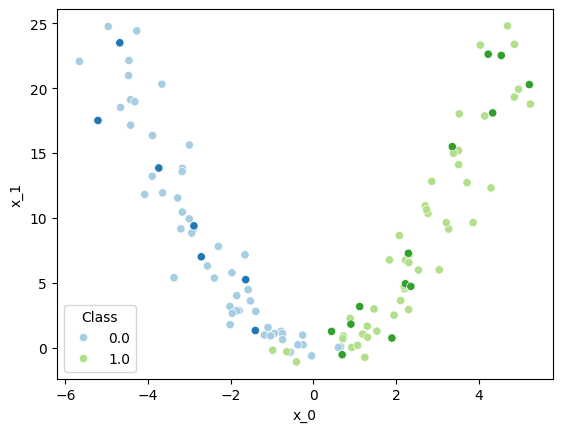

In [5]:
"""
Gen Datasets
"""

def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])


size = config['data_params']['train_size'] + config['data_params']['validation_size']


X = np.array([(x,x**2) for x in np.linspace(-5,5,size)]) + jax.random.normal(noise_key,(size,2))*0.5 # multiply by scaling factor

Y = np.zeros_like(X[:,0])
Y[int(size/2 + size%2):] = 1

y_preds = optimum_classifier(X)

# sample training set
sample_indices = jax.random.randint(sample_key,config['data_params']['train_size'],0,size,)
sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 

X_train = np.array([X[i] for i in sample_indices])
Y_train = np.array([Y[i] for i in sample_indices])


X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train[:,0],
                         'x_1':X_train[:,1],
                         'Class':Y_train})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})


if config['visualisation']['visualise']:
#     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
    test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
    train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)

In [6]:

train_dataset = data.TensorDataset(torch.tensor(X_train),torch.tensor(Y_train))
train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=False, generator=torch.Generator().manual_seed(seed))

test_dataset = data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test))
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False, generator=torch.Generator().manual_seed(seed))

model = custom_models.SimpleClassifier(*config['hyperparams']['model_io'])
trained_state, model = ut.create_train_state(model,optimiser,vector_length=2, key=model_key)

data_name = "X2"
model_name = config['hyperparams']['model']
output_name = f"MODEL_ENSEMBLE_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{batch_size}__DATA_{data_name}__LOSS_{loss_name}_alpha_2__SIZE_{config['data_params']['train_size']}"

print("Loading and saving to : ", output_name)


Loading and saving to :  MODEL_ENSEMBLE_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA_X2__LOSS_cross_entropy_alpha_2__SIZE_20


In [9]:

results= {
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}}

if not overwrite:
    try:
        print('Test')
        with open(output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)
        print('Test2')
        trained_state.replace(params = res['params'])
        
        results = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass
        
        

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

n_epochs = 10

for epoch in tqdm(range(n_epochs)):
    trained_state, train_metrics = ut.train_one_epoch(trained_state, train_dataloader,  
                                                    # model, loss_functions['direction_interactive_vectorized'])
                                                #  model, loss_functions['direction_interactive'])
                                                # model, loss_functions['direction_interactive2'])
                                                #  model, loss_functions['gradient_supervision'],rng)
                                                #  model, loss_functions['direction'],rng)
                                                model, loss_functions.loss_functions[loss_name],model_key)
    
    plot_states.append(trained_state)
    
    

                                                #  model, loss_functions['cross_entropy_l2'])
                                        
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    
    train_metrics = ut.generate_results({'X':X_train,'Y':Y_train},model,trained_state.params,name="Train")
    val_metrics = ut.generate_results({'X':X_test,'Y':Y_test},model,trained_state.params,name="Validation")
    


    results['Train']['losses'].append(train_metrics['loss'])
    results['Train']['accuracy'].append(train_metrics['accuracy'])
    
    results['Validation']['losses'].append(val_metrics['loss'])
    results['Validation']['accuracy'].append(val_metrics['accuracy'])
    


 40%|████      | 4/10 [00:00<00:00, 16.13it/s]

Train Loss: 0.5203916430473328, Train Accuracy: 100.0
Validation Loss: 0.5608283281326294, Validation Accuracy: 88.0
Train Loss: 0.5005437135696411, Train Accuracy: 100.0
Validation Loss: 0.5455624461174011, Validation Accuracy: 90.0
Train Loss: 0.48102006316185, Train Accuracy: 100.0
Validation Loss: 0.5307508707046509, Validation Accuracy: 90.0
Train Loss: 0.45989903807640076, Train Accuracy: 100.0
Validation Loss: 0.5154158473014832, Validation Accuracy: 90.0
Train Loss: 0.437176913022995, Train Accuracy: 100.0
Validation Loss: 0.49988844990730286, Validation Accuracy: 90.0


100%|██████████| 10/10 [00:00<00:00, 18.59it/s]

Train Loss: 0.4177165925502777, Train Accuracy: 100.0
Validation Loss: 0.4863537549972534, Validation Accuracy: 89.0
Train Loss: 0.40336495637893677, Train Accuracy: 100.0
Validation Loss: 0.4754506051540375, Validation Accuracy: 89.0
Train Loss: 0.3915092647075653, Train Accuracy: 100.0
Validation Loss: 0.46581965684890747, Validation Accuracy: 91.0
Train Loss: 0.38033294677734375, Train Accuracy: 100.0
Validation Loss: 0.45644721388816833, Validation Accuracy: 91.0
Train Loss: 0.3691169023513794, Train Accuracy: 100.0
Validation Loss: 0.4468795359134674, Validation Accuracy: 91.0


In [10]:
output = {'results':results,
          'params':trained_state.params}

total_epochs = len(results['Train']['accuracy'])

print(f'Model saved to {output_name} as:\n\n{output_name}. \nTrained for {n_epochs} epochs (Total: {total_epochs})')
os.makedirs('outputs',exist_ok=True)
with open(os.path.join('outputs',output_name) + '.pkl', 'wb') as file:
    pickle.dump(output,file)

if config['visualisation']['video']:
    ut.plotEpoch(
          X_test,Y_test,
          model,
          plot_states,
          plot_type='video',
          name = output_name,
          key = model_key)

Model saved to MODEL_ENSEMBLE_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA_X2__LOSS_cross_entropy_alpha_2__SIZE_20 as:

MODEL_ENSEMBLE_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA_X2__LOSS_cross_entropy_alpha_2__SIZE_20. 
Trained for 10 epochs (Total: 10)


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.1.0.2.5)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspee